In [1]:
pip install mne


Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 19.0 MB/s eta 0:00:00a 0:00:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [mne]
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import mne
import numpy as np

DATA_DIR = "/Users/duanx3/Documents/eeg-motor-movementimagery-dataset-1.0.0"
OUT_DIR  = os.path.join(DATA_DIR, "EEGMI_numpy")

subjects = range(1, 110)
runs     = range(1, 15)

os.makedirs(OUT_DIR, exist_ok=True)

for s in subjects:
    subj = f"S{s:03d}"
    subj_dir = os.path.join(DATA_DIR, subj)
    if not os.path.isdir(subj_dir):
        print(f"Skipping missing subject {subj}")
        continue

    out_subj = os.path.join(OUT_DIR, subj)
    os.makedirs(out_subj, exist_ok=True)

    print(f"\n=== Processing {subj} ===")

    for r in runs:
        fname = f"{subj}R{r:02d}.edf"
        fpath = os.path.join(subj_dir, fname)
        if not os.path.isfile(fpath):
            print(f"  Missing {fname}")
            continue

        print(f"  Loading {fname} ...")

        # Load EDF using MNE
        raw = mne.io.read_raw_edf(fpath, preload=True, verbose=False)

        # Pick only the 64 EEG channels (MNE loads extra annotation channels)
        eeg_picks = mne.pick_types(raw.info, eeg=True, misc=False)
        data = raw.get_data(picks=eeg_picks).T   # shape → (T, 64)

        # Z-score per channel
        mu = data.mean(axis=0, keepdims=True)
        sigma = data.std(axis=0, keepdims=True) + 1e-6
        data_z = (data - mu) / sigma

        # Save as NumPy file
        out_path = os.path.join(out_subj, f"{subj}R{r:02d}.npy")
        np.save(out_path, data_z)

        print(f"  Saved {out_path}  (shape={data_z.shape})")

print("\n=========================================")
print("   Finished conversion to NumPy format")
print("   Output folder:", OUT_DIR)
print("=========================================")



=== Processing S001 ===
  Loading S001R01.edf ...
  Saved /Users/duanx3/Documents/eeg-motor-movementimagery-dataset-1.0.0/EEGMI_numpy/S001/S001R01.npy  (shape=(9760, 64))
  Loading S001R02.edf ...
  Saved /Users/duanx3/Documents/eeg-motor-movementimagery-dataset-1.0.0/EEGMI_numpy/S001/S001R02.npy  (shape=(9760, 64))
  Loading S001R03.edf ...
  Saved /Users/duanx3/Documents/eeg-motor-movementimagery-dataset-1.0.0/EEGMI_numpy/S001/S001R03.npy  (shape=(20000, 64))
  Loading S001R04.edf ...
  Saved /Users/duanx3/Documents/eeg-motor-movementimagery-dataset-1.0.0/EEGMI_numpy/S001/S001R04.npy  (shape=(20000, 64))
  Loading S001R05.edf ...
  Saved /Users/duanx3/Documents/eeg-motor-movementimagery-dataset-1.0.0/EEGMI_numpy/S001/S001R05.npy  (shape=(20000, 64))
  Loading S001R06.edf ...
  Saved /Users/duanx3/Documents/eeg-motor-movementimagery-dataset-1.0.0/EEGMI_numpy/S001/S001R06.npy  (shape=(20000, 64))
  Loading S001R07.edf ...
  Saved /Users/duanx3/Documents/eeg-motor-movementimagery-datas

/var/folders/2b/j4_0xvfd2yn858rh_853wd8h9f4j83/T/ipykernel_64639/2949875817.py:35: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(fpath, preload=True, verbose=False)
/var/folders/2b/j4_0xvfd2yn858rh_853wd8h9f4j83/T/ipykernel_64639/2949875817.py:35: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(fpath, preload=True, verbose=False)
/var/folders/2b/j4_0xvfd2yn858rh_853wd8h9f4j83/T/ipykernel_64639/2949875817.py:35: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(fpath, preload=True, verbose=False)
/var/folders/2b/j4_0xvfd2yn858rh_853wd8h9f4j83/T/ipykernel_64639/2949875817.py:35: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(fpath, preload=True, verbose=False)
/var/folders/2b/j4_0xvfd2yn858rh_853wd8h9f4j83/T/ipykernel_64639/2949875817.

  Saved /Users/duanx3/Documents/eeg-motor-movementimagery-dataset-1.0.0/EEGMI_numpy/S101/S101R04.npy  (shape=(20000, 64))
  Loading S101R05.edf ...
  Saved /Users/duanx3/Documents/eeg-motor-movementimagery-dataset-1.0.0/EEGMI_numpy/S101/S101R05.npy  (shape=(20000, 64))
  Loading S101R06.edf ...
  Saved /Users/duanx3/Documents/eeg-motor-movementimagery-dataset-1.0.0/EEGMI_numpy/S101/S101R06.npy  (shape=(20000, 64))
  Loading S101R07.edf ...
  Saved /Users/duanx3/Documents/eeg-motor-movementimagery-dataset-1.0.0/EEGMI_numpy/S101/S101R07.npy  (shape=(20000, 64))
  Loading S101R08.edf ...
  Saved /Users/duanx3/Documents/eeg-motor-movementimagery-dataset-1.0.0/EEGMI_numpy/S101/S101R08.npy  (shape=(20000, 64))
  Loading S101R09.edf ...
  Saved /Users/duanx3/Documents/eeg-motor-movementimagery-dataset-1.0.0/EEGMI_numpy/S101/S101R09.npy  (shape=(20000, 64))
  Loading S101R10.edf ...
  Saved /Users/duanx3/Documents/eeg-motor-movementimagery-dataset-1.0.0/EEGMI_numpy/S101/S101R10.npy  (shape=(20

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os


In [4]:
# Path to your numpy data folder
BASE = "/Users/duanx3/Documents/eeg-motor-movementimagery-dataset-1.0.0/EEGMI_numpy"

subj = "S001"
run  = "S001R01.npy"

fpath = os.path.join(BASE, subj, run)
X = np.load(fpath)   # shape = (T, 64)

print("Loaded", fpath)
print("Shape:", X.shape)


Loaded /Users/duanx3/Documents/eeg-motor-movementimagery-dataset-1.0.0/EEGMI_numpy/S001/S001R01.npy
Shape: (9760, 64)


In [5]:
fs = 160.0   # verified earlier
T = X.shape[0]
t = np.arange(T) / fs


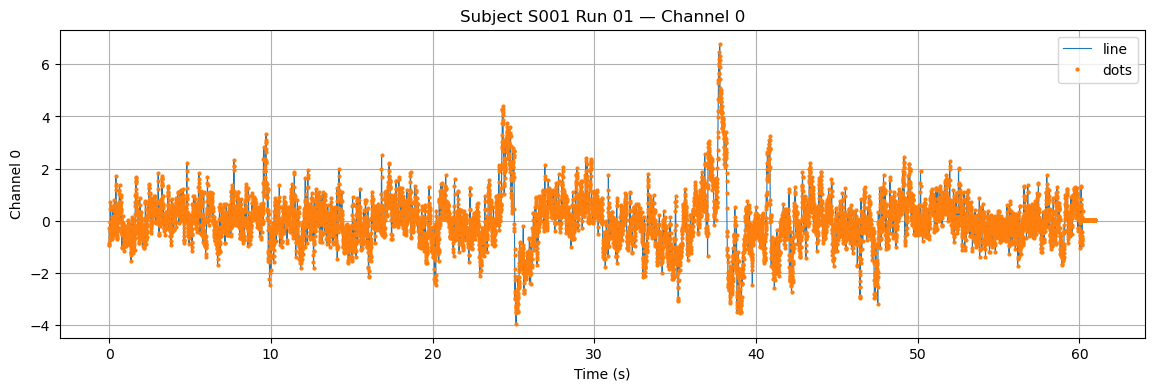

In [6]:
channel = 0   # e.g., channel 0 (Fp1 if ordering matches EDF)

y = X[:, channel]

plt.figure(figsize=(14, 4))
plt.plot(t, y, '-', linewidth=0.8, label="line")
plt.plot(t, y, '.', markersize=4, label="dots")

plt.xlabel("Time (s)")
plt.ylabel(f"Channel {channel}")
plt.title("Subject S001 Run 01 — Channel {}".format(channel))
plt.grid(True)
plt.legend()
plt.show()


Number of samples in this 1-second interval = 160


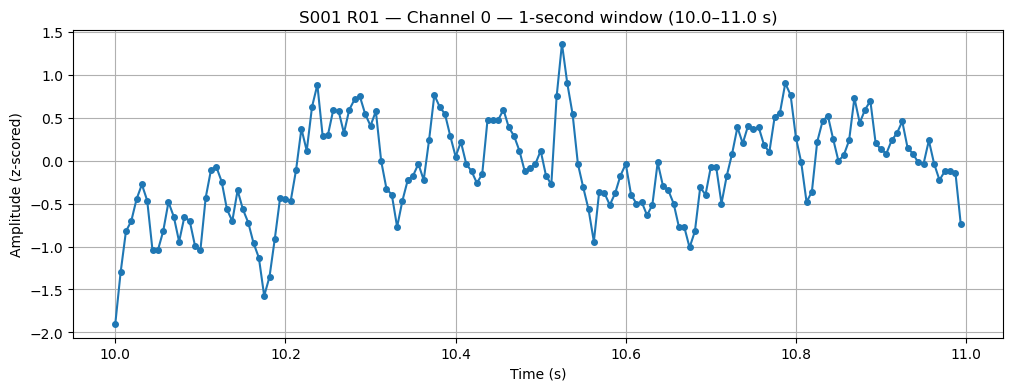

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# --- Load data ---
subj = "S001"
run  = "R01"
data_root = "/Users/duanx3/Documents/eeg-motor-movementimagery-dataset-1.0.0/EEGMI_numpy"

X = np.load(f"{data_root}/{subj}/{subj}{run}.npy")   # shape (T, 64)
fs = 160                                             # sampling rate
channel = 0                                          # pick channel 0

# --- Build time vector ---
T = X.shape[0]
t = np.arange(T) / fs

# --- Select 1-second interval ---
t0 = 10.0               # start time in sec
t1 = 11.0               # end time in sec
mask = (t >= t0) & (t < t1)

t_sec = t[mask]
x_sec = X[mask, channel]

print("Number of samples in this 1-second interval =", len(t_sec))

# --- Plot ---
plt.figure(figsize=(12,4))
plt.plot(t_sec, x_sec, '-o', markersize=4)
plt.title(f"{subj} {run} — Channel {channel} — 1-second window ({t0}–{t1} s)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (z-scored)")
plt.grid(True)
plt.show()
